In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("Device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
CUDA build: 12.8
CUDA available: True
Device count: 1
GPU: NVIDIA GeForce RTX 5060 Laptop GPU


In [2]:
from datasets import load_dataset

dataset = load_dataset("dair-ai/emotion", "split")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


In [3]:
print(dataset["train"][0])

{'text': 'i didnt feel humiliated', 'label': 0}


 Emotion Classification Using Traditional Machine Learning and a BERT-Style Model

 Project overview

This project investigates multiclass emotion classification using the `dair-ai/emotion` dataset. The aim is to classify English text into one of six emotion categories: sadness, joy, love, anger, fear, or surprise.

A traditional machine-learning baseline will be developed and compared with a fine-tuned BERT-style transformer model. Both models will be evaluated using accuracy, precision, recall, and F1-score.

In [4]:
# Display the dataset structure and available label names
print(dataset)

label_names = dataset["train"].features["label"].names

print("\nEmotion labels:")
for label_id, label_name in enumerate(label_names):
    print(f"{label_id}: {label_name}")

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

Emotion labels:
0: sadness
1: joy
2: love
3: anger
4: fear
5: surprise


In [5]:
import pandas as pd

# Convert each Hugging Face dataset split into a pandas DataFrame
train_df = dataset["train"].to_pandas()
validation_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

print("Training shape:", train_df.shape)
print("Validation shape:", validation_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Training shape: (16000, 2)
Validation shape: (2000, 2)
Test shape: (2000, 2)


,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [6]:
def check_data_quality(df, split_name):
    print(f"\n{split_name} split")

    print("Rows:", len(df))
    print("Missing values:")
    print(df.isnull().sum())

    empty_texts = df["text"].astype(str).str.strip().eq("").sum()
    duplicate_rows = df.duplicated().sum()
    duplicate_texts = df.duplicated(subset="text").sum()

    print("Empty text entries:", empty_texts)
    print("Fully duplicated rows:", duplicate_rows)
    print("Duplicated text entries:", duplicate_texts)


check_data_quality(train_df, "Training")
check_data_quality(validation_df, "Validation")
check_data_quality(test_df, "Test")


Training split
Rows: 16000
Missing values:
text     0
label    0
dtype: int64
Empty text entries: 0
Fully duplicated rows: 1
Duplicated text entries: 31

Validation split
Rows: 2000
Missing values:
text     0
label    0
dtype: int64
Empty text entries: 0
Fully duplicated rows: 0
Duplicated text entries: 2

Test split
Rows: 2000
Missing values:
text     0
label    0
dtype: int64
Empty text entries: 0
Fully duplicated rows: 0
Duplicated text entries: 0


In [7]:
#Check whether duplicated texts have consistent or conflicting labels.
def inspect_duplicate_labels(df, split_name):
    duplicate_texts = df[df.duplicated(subset="text", keep=False)].sort_values("text")

    if duplicate_texts.empty:
        print(f"{split_name}: No duplicated texts found.")
        return

    label_counts = duplicate_texts.groupby("text")["label"].nunique()

    consistent_duplicates = (label_counts == 1).sum()
    conflicting_duplicates = (label_counts > 1).sum()

    print(f"\n{split_name}")
    print("Unique duplicated texts:", len(label_counts))
    print("Duplicates with the same label:", consistent_duplicates)
    print("Duplicates with conflicting labels:", conflicting_duplicates)


inspect_duplicate_labels(train_df, "Training")
inspect_duplicate_labels(validation_df, "Validation")
inspect_duplicate_labels(test_df, "Test")


Training
Unique duplicated texts: 31
Duplicates with the same label: 1
Duplicates with conflicting labels: 30

Validation
Unique duplicated texts: 2
Duplicates with the same label: 0
Duplicates with conflicting labels: 2
Test: No duplicated texts found.


In [8]:
#Count identical texts appearing in two different dataset splits.
def check_split_overlap(df_a, df_b, name_a, name_b):
    
    texts_a = set(df_a["text"])
    texts_b = set(df_b["text"])

    overlap = texts_a.intersection(texts_b)

    print(f"{name_a} vs {name_b}: {len(overlap)} overlapping texts")

    return overlap


train_validation_overlap = check_split_overlap(
    train_df, validation_df, "Training", "Validation"
)

train_test_overlap = check_split_overlap(
    train_df, test_df, "Training", "Test"
)

validation_test_overlap = check_split_overlap(
    validation_df, test_df, "Validation", "Test"
)

Training vs Validation: 5 overlapping texts
Training vs Test: 11 overlapping texts
Validation vs Test: 3 overlapping texts


In [9]:
#Remove texts associated with more than one label and keep one copy of texts that have the same label.

def clean_conflicting_duplicates(df):
    df = df.copy()

    #count number of unique lablels
    label_counts = df.groupby("text")["label"].nunique()

    # ambiguous texts assigned to multiple labels
    conflicting_texts = label_counts[label_counts > 1].index

    #remove every occurence of conflicting text
    df = df[~df["text"].isin(conflicting_texts)]

    #one copy of consistent duplicated rows
    df = df.drop_duplicates(subset=["text", "label"]).reset_index(drop=True)

    return df


#remove conflicting and repeated examples within each split
train_clean = clean_conflicting_duplicates(train_df)
validation_clean = clean_conflicting_duplicates(validation_df)
test_clean = clean_conflicting_duplicates(test_df)


#remove validation exampples also in trainging
validation_clean = validation_clean[
    ~validation_clean["text"].isin(set(train_clean["text"]))
].reset_index(drop=True)


#remove test examples that occur in training or validation
evaluation_texts = set(train_clean["text"]) | set(validation_clean["text"])

test_clean = test_clean[
    ~test_clean["text"].isin(evaluation_texts)
].reset_index(drop=True)


print("Original and cleaned dataset sizes")
print(f"Training:   {len(train_df)} → {len(train_clean)}")
print(f"Validation: {len(validation_df)} → {len(validation_clean)}")
print(f"Test:       {len(test_df)} → {len(test_clean)}")

Original and cleaned dataset sizes
Training:   16000 → 15939
Validation: 2000 → 1991
Test:       2000 → 1986


In [10]:
print(
    "Training vs validation:",
    len(set(train_clean["text"]) & set(validation_clean["text"]))
)

print(
    "Training vs test:",
    len(set(train_clean["text"]) & set(test_clean["text"]))
)

print(
    "Validation vs test:",
    len(set(validation_clean["text"]) & set(test_clean["text"]))
)

Training vs validation: 0
Training vs test: 0
Validation vs test: 0


In [11]:
#label mapping
label_mapping = {
    0: "sadness",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise"
}

for df in [train_clean, validation_clean, test_clean]:
    df["emotion"] = df["label"].map(label_mapping)

#display class count for each label
for split_name, df in {
    "Training": train_clean,
    "Validation": validation_clean,
    "Test": test_clean
}.items():
    print(f"\n{split_name} class distribution")
    print(df["emotion"].value_counts())


Training class distribution
emotion
joy         5345
sadness     4662
anger       2152
fear        1926
love        1289
surprise     565
Name: count, dtype: int64

Validation class distribution
emotion
joy         701
sadness     550
anger       274
fear        211
love        174
surprise     81
Name: count, dtype: int64

Test class distribution
emotion
joy         688
sadness     579
anger       274
fear        224
love        156
surprise     65
Name: count, dtype: int64


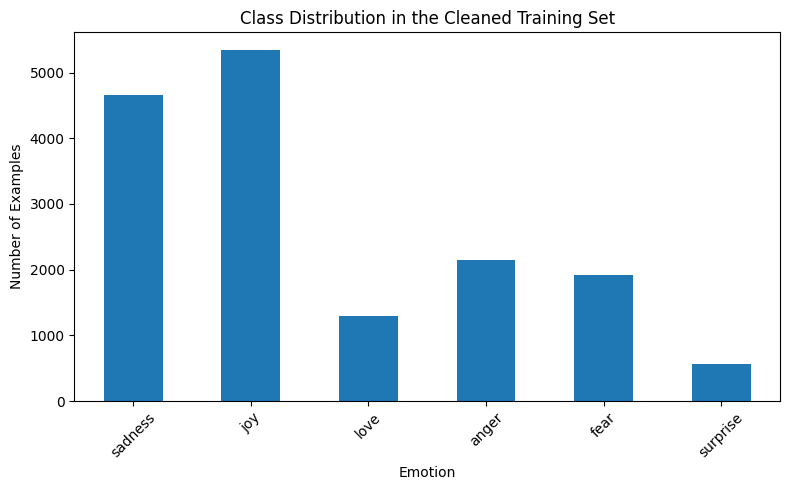

In [12]:
import matplotlib.pyplot as plt

train_class_counts = (
    train_clean["emotion"]
    .value_counts()
    .reindex(label_mapping.values())
)

plt.figure(figsize=(8, 5))
train_class_counts.plot(kind="bar")

plt.title("Class Distribution in the Cleaned Training Set")
plt.xlabel("Emotion")
plt.ylabel("Number of Examples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
#text-length features
for df in [train_clean, validation_clean, test_clean]:
    df["word_count"] = df["text"].str.split().str.len()
    df["character_count"] = df["text"].str.len()

#summary stats
train_clean[["word_count", "character_count"]].describe()

,word_count,character_count
count,15939.000000,15939.000000
mean,19.176674,96.900621
std,10.994633,55.947861
min,2.000000,7.000000
25%,11.000000,53.000000
50%,17.000000,86.000000
75%,25.000000,129.000000
max,66.000000,300.000000


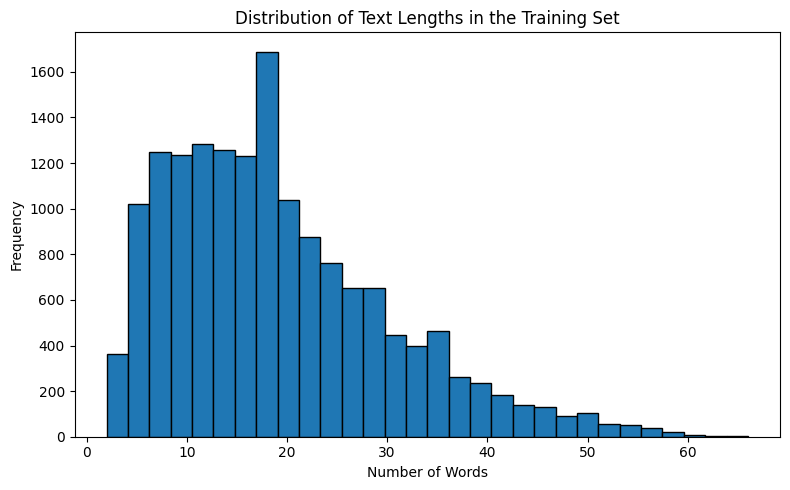

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(train_clean["word_count"], bins=30, edgecolor="black")

plt.title("Distribution of Text Lengths in the Training Set")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [15]:
print("Maximum word count:", train_clean["word_count"].max())
print("95th percentile:", train_clean["word_count"].quantile(0.95))
print("99th percentile:", train_clean["word_count"].quantile(0.99))

Maximum word count: 66
95th percentile: 41.0
99th percentile: 52.0


Most texts in the dataset are short. The maximum observed length is 66 words, while 99% of training examples contain 52 words or fewer. This suggests that a relatively small transformer sequence length may be sufficient, reducing memory usage and training time. The final maximum sequence length will be confirmed using the selected model tokenizer.

In [16]:
#Display a small number of text examples from each emotion class.
    
def show_examples_by_emotion(df, examples_per_class=3):
    for emotion in label_mapping.values():
        print(f"\n{emotion.upper()}")

        examples = (
            df[df["emotion"] == emotion]
            .sample(n=examples_per_class, random_state=42)
            ["text"]
        )

        for index, text in enumerate(examples, start=1):
            print(f"{index}. {text}")


show_examples_by_emotion(train_clean, examples_per_class=3)


SADNESS
1. i am not feeling shitty about life anymore
2. i did feel defeated
3. i was left feeling a little disappointed since it all started so well and finished a little limply

JOY
1. i feel like i am not special
2. i nuh must feel joyful and victorious
3. i feel like being sociable having someone over or going out and chilling somewhere

LOVE
1. i feel so blessed to be apart of it
2. i did feel sympathy for him and liked him more by the end of the story however i dont feel that enough time was spent on his turn around
3. i certainly feel loved and appreciated and grateful for all that i have

ANGER
1. i imagine you re going to come away from it feeling a little jealous you can t quite
2. i feel i am kinda pissed off
3. i was dwelling on the current state of my life i was unsure about my place in life and what i was going to do with it and i was feeling a bit bitter at god because of it

FEAR
1. i almost feel intimidated by the attempt to describe it
2. i lve the fact that yu genui

 Baseline Model: TF-IDF with Logistic Regression

The baseline model represents each text using Term Frequency–Inverse Document Frequency (TF-IDF) features and performs multiclass classification using Logistic Regression.

This provides a strong traditional machine-learning benchmark against which the fine-tuned transformer model can be compared.

In [17]:
#separate the text features and numerical labels for each split
X_train = train_clean["text"]
y_train = train_clean["label"]

X_validation = validation_clean["text"]
y_validation = validation_clean["label"]

X_test = test_clean["text"]
y_test = test_clean["label"]

print("Training examples:", len(X_train))
print("Validation examples:", len(X_validation))
print("Test examples:", len(X_test))

Training examples: 15939
Validation examples: 1991
Test examples: 1986


In [18]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

baseline_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            min_df=2,
            max_features=20000
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )
    )
])

baseline_pipeline

,steps,"[('tfidf', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [19]:
baseline_pipeline.fit(X_train, y_train)

print("Baseline model training completed.")

Baseline model training completed.


In [20]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report
)

#generate validation predictions
validation_predictions = baseline_pipeline.predict(X_validation)

#calculate overall multiclass metrics
validation_accuracy = accuracy_score(
    y_validation,
    validation_predictions
)

validation_precision, validation_recall, validation_f1, _ = (
    precision_recall_fscore_support(
        y_validation,
        validation_predictions,
        average="macro",
        zero_division=0
    )
)

print("Baseline validation performance")
print(f"Accuracy:        {validation_accuracy:.4f}")
print(f"Macro precision: {validation_precision:.4f}")
print(f"Macro recall:    {validation_recall:.4f}")
print(f"Macro F1-score:  {validation_f1:.4f}")

print("\nClassification report")
print(
    classification_report(
        y_validation,
        validation_predictions,
        target_names=label_names,
        zero_division=0
    )
)

Baseline validation performance
Accuracy:        0.8785
Macro precision: 0.8365
Macro recall:    0.8673
Macro F1-score:  0.8496

Classification report
              precision    recall  f1-score   support

     sadness       0.91      0.88      0.90       550
         joy       0.93      0.88      0.90       701
        love       0.75      0.94      0.84       174
       anger       0.88      0.89      0.89       274
        fear       0.83      0.81      0.82       211
    surprise       0.71      0.79      0.75        81

    accuracy                           0.88      1991
   macro avg       0.84      0.87      0.85      1991
weighted avg       0.88      0.88      0.88      1991



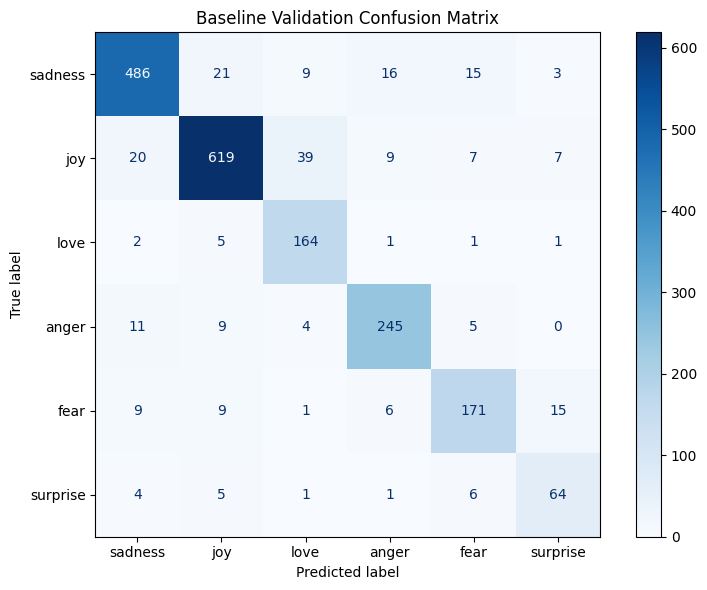

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

validation_cm = confusion_matrix(
    y_validation,
    validation_predictions
)

display = ConfusionMatrixDisplay(
    confusion_matrix=validation_cm,
    display_labels=label_names
)

fig, ax = plt.subplots(figsize=(8, 6))
display.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

plt.title("Baseline Validation Confusion Matrix")
plt.tight_layout()
plt.show()

The baseline confusion matrix shows strong classification performance for the larger classes, particularly joy, sadness, and anger. The most notable confusion occurs between joy and love, where several joy examples are predicted as love. Fear and surprise are also occasionally confused, reflecting conceptual overlap between these emotions. These errors suggest that contextual understanding may help improve performance beyond the TF-IDF baseline.

In [22]:
from sklearn.metrics import accuracy_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import pandas as pd

baseline_results = []

ngram_options = [(1, 1), (1, 2)]
c_values = [0.5, 1.0, 2.0]

for ngram_range in ngram_options:
    for c_value in c_values:

        model = Pipeline([
            (
                "tfidf",
                TfidfVectorizer(
                    lowercase=True,
                    ngram_range=ngram_range,
                    min_df=2,
                    max_features=20000
                )
            ),
            (
                "classifier",
                LogisticRegression(
                    C=c_value,
                    max_iter=1000,
                    class_weight="balanced",
                    random_state=42
                )
            )
        ])

        model.fit(X_train, y_train)
        predictions = model.predict(X_validation)

        baseline_results.append({
            "ngram_range": str(ngram_range),
            "C": c_value,
            "validation_accuracy": accuracy_score(
                y_validation,
                predictions
            ),
            "validation_macro_f1": f1_score(
                y_validation,
                predictions,
                average="macro"
            )
        })

baseline_tuning_df = pd.DataFrame(baseline_results)

baseline_tuning_df.sort_values(
    by="validation_macro_f1",
    ascending=False
).reset_index(drop=True)

,ngram_range,C,validation_accuracy,validation_macro_f1
0,"(1, 1)",2.0,0.893019,0.872287
1,"(1, 1)",1.0,0.889503,0.867990
2,"(1, 2)",2.0,0.889503,0.860621
3,"(1, 1)",0.5,0.881467,0.857579
4,"(1, 2)",1.0,0.878453,0.849619
5,"(1, 2)",0.5,0.859869,0.832583


In [23]:
best_baseline_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 1),
            min_df=2,
            max_features=20000
        )
    ),
    (
        "classifier",
        LogisticRegression(
            C=2.0,
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )
    )
])

best_baseline_pipeline.fit(X_train, y_train)

print("Best baseline model trained successfully.")

Best baseline model trained successfully.


In [24]:
best_validation_predictions = best_baseline_pipeline.predict(X_validation)

best_baseline_validation_accuracy = accuracy_score(
    y_validation,
    best_validation_predictions
)

best_baseline_validation_macro_f1 = f1_score(
    y_validation,
    best_validation_predictions,
    average="macro"
)

print("Best baseline validation accuracy:",
      round(best_baseline_validation_accuracy, 4))

print("Best baseline validation macro F1:",
      round(best_baseline_validation_macro_f1, 4))

Best baseline validation accuracy: 0.893
Best baseline validation macro F1: 0.8723


The best baseline configuration used unigram TF-IDF features with Logistic Regression and `C=2.0`. It achieved a validation accuracy of 0.8930 and a macro F1-score of 0.8723. This configuration outperformed the unigram-plus-bigram alternatives, suggesting that single-word features were sufficient for this dataset and that the additional bigram feature space did not improve generalisation.

 Fine-Tuned DistilBERT Model

The second model uses distilbert-base-uncased, a lighter version of BERT. The pre-trained transformer will be fine-tuned to classify each text into one of six emotion categories.

Before tokenising the full dataset, the distribution of tokenised sequence lengths is examined to select an appropriate maximum sequence length.

In [25]:
from transformers import AutoTokenizer

model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

print("Tokenizer loaded successfully.")
print("Model:", model_name)
print("Vocabulary size:", tokenizer.vocab_size)
print("Maximum supported length:", tokenizer.model_max_length)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

c:\Users\sagal\OneDrive\Desktop\Let us build\LLM project\llm_env\lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\sagal\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizer loaded successfully.
Model: distilbert-base-uncased
Vocabulary size: 30522
Maximum supported length: 512


In [26]:
sample_text = train_clean["text"].iloc[0]

sample_encoding = tokenizer(
    sample_text,
    truncation=True,
    padding=False
)

print("Original text:")
print(sample_text)

print("\nToken IDs:")
print(sample_encoding["input_ids"])

print("\nTokens:")
print(tokenizer.convert_ids_to_tokens(sample_encoding["input_ids"]))

Original text:
i didnt feel humiliated

Token IDs:
[101, 1045, 2134, 2102, 2514, 26608, 102]

Tokens:
['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]']


In [27]:
def calculate_token_lengths(texts, tokenizer):
    """
    Calculate the number of transformer tokens in each text,
    including special tokens added by the tokenizer.
    """
    return [
        len(
            tokenizer(
                text,
                add_special_tokens=True,
                truncation=False
            )["input_ids"]
        )
        for text in texts
    ]


train_token_lengths = calculate_token_lengths(
    train_clean["text"],
    tokenizer
)

print("Maximum token length:", max(train_token_lengths))
print("95th percentile:", pd.Series(train_token_lengths).quantile(0.95))
print("99th percentile:", pd.Series(train_token_lengths).quantile(0.99))

Maximum token length: 87
95th percentile: 45.0
99th percentile: 57.0


The DistilBERT tokenizer produced a maximum sequence length of 87 tokens, while 99% of the training texts contained 57 tokens or fewer. Therefore, a maximum sequence length of 64 tokens was selected to preserve nearly all text while reducing computational cost.

In [28]:
from datasets import Dataset, DatasetDict

# Keep only the columns required for model training
train_hf = Dataset.from_pandas(
    train_clean[["text", "label"]],
    preserve_index=False
)

validation_hf = Dataset.from_pandas(
    validation_clean[["text", "label"]],
    preserve_index=False
)

test_hf = Dataset.from_pandas(
    test_clean[["text", "label"]],
    preserve_index=False
)

clean_dataset = DatasetDict({
    "train": train_hf,
    "validation": validation_hf,
    "test": test_hf
})

print(clean_dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 15939
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1991
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1986
    })
})


In [29]:
MAX_LENGTH = 64

def tokenize_batch(batch):
    """
    Tokenize a batch of texts for DistilBERT classification.
    """
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH
    )


tokenized_dataset = clean_dataset.map(
    tokenize_batch,
    batched=True
)

print(tokenized_dataset)

Map:   0%|          | 0/15939 [00:00<?, ? examples/s]

Map:   0%|          | 0/1991 [00:00<?, ? examples/s]

Map:   0%|          | 0/1986 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 15939
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1991
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1986
    })
})


In [30]:
# Remove the original text column because the model only needs tensors and labels
tokenized_dataset = tokenized_dataset.remove_columns(["text"])

# Rename label to labels because Hugging Face models expect this field name
tokenized_dataset = tokenized_dataset.rename_column("label", "labels")

# Return PyTorch tensors when examples are accessed
tokenized_dataset.set_format("torch")

print(tokenized_dataset)

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 15939
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1991
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1986
    })
})


In [31]:
sample = tokenized_dataset["train"][0]

print("Input IDs shape:", sample["input_ids"].shape)
print("Attention mask shape:", sample["attention_mask"].shape)
print("Label:", sample["labels"])

Input IDs shape: torch.Size([64])
Attention mask shape: torch.Size([64])
Label: tensor(0)


In [32]:
from transformers import AutoModelForSequenceClassification

num_labels = len(label_names)

id2label = {
    index: label
    for index, label in enumerate(label_names)
}

label2id = {
    label: index
    for index, label in enumerate(label_names)
}

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

print("Model loaded successfully.")
print("Number of labels:", model.config.num_labels)
print("Label mapping:", model.config.id2label)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded successfully.
Number of labels: 6
Label mapping: {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}


In [33]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model.to(device)

print("Using device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU


 Training and Evaluation Setup

The DistilBERT model is fine-tuned using the training split and evaluated on the validation split after each epoch. Model selection is based on macro F1-score because the emotion classes are imbalanced.

In [34]:
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)


def compute_metrics(eval_prediction):
    """
    Calculate multiclass evaluation metrics for DistilBERT.

    Macro averaging gives equal importance to each emotion class,
    while weighted F1 accounts for the number of examples per class.
    """
    logits, labels = eval_prediction
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)

    macro_precision, macro_recall, macro_f1, _ = (
        precision_recall_fscore_support(
            labels,
            predictions,
            average="macro",
            zero_division=0
        )
    )

    weighted_f1 = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )[2]

    return {
        "accuracy": accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1
    }

In [35]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

print("Metric function and data collator created successfully.")

Metric function and data collator created successfully.


In [36]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./distilbert_experiment_1",

    # Training configuration
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,

    # Evaluate and save after every epoch
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",

    # Keep the checkpoint with the best validation macro F1
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    # GPU mixed-precision training
    fp16=True,

    # Reproducibility and checkpoint management
    seed=42,
    save_total_limit=1,

    # Prevent external experiment-tracking prompts
    report_to="none"
)

print("Training arguments created successfully.")

Training arguments created successfully.


In [37]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print("Trainer created successfully.")

Trainer created successfully.


In [38]:
print("Model device:", next(model.parameters()).device)
print("Training examples:", len(tokenized_dataset["train"]))
print("Validation examples:", len(tokenized_dataset["validation"]))

Model device: cuda:0
Training examples: 15939
Validation examples: 1991


In [39]:
training_result = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
1,0.489089,0.233701,0.924661,0.916749,0.890042,0.899311,0.924574
2,0.148707,0.152841,0.943245,0.915873,0.923649,0.919205,0.943198
3,0.095778,0.146396,0.943245,0.920430,0.917183,0.918529,0.943188


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [40]:
experiment_1_metrics = trainer.evaluate()

print("Experiment 1 validation metrics")


for metric_name, metric_value in experiment_1_metrics.items():
    if isinstance(metric_value, float):
        print(f"{metric_name}: {metric_value:.4f}")
    else:
        print(f"{metric_name}: {metric_value}")

Training Loss,Validation Loss,Epoch,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0.095778,0.152841,3,0.943245,0.915873,0.923649,0.919205,0.943198


Experiment 1 validation metrics
eval_loss: 0.1528
eval_accuracy: 0.9432
eval_macro_precision: 0.9159
eval_macro_recall: 0.9236
eval_macro_f1: 0.9192
eval_weighted_f1: 0.9432


 DistilBERT Experiment 1 Results

The first DistilBERT configuration used a learning rate of 2e-5, a training batch size of 16, and three epochs. It achieved a validation accuracy of 0.9432 and a macro F1-score of 0.9192.

Compared with the tuned TF-IDF Logistic Regression baseline, DistilBERT improved validation accuracy from 0.8930 to 0.9432 and macro F1-score from 0.8723 to 0.9192. This indicates that contextual transformer representations provide a clear advantage for multiclass emotion classification.

In [41]:
import pandas as pd

training_history = pd.DataFrame(trainer.state.log_history)

training_history

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_macro_precision,eval_macro_recall,eval_macro_f1,eval_weighted_f1,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.489089,0.248352,1.334002e-05,1.0,997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,1.0,997,0.233701,0.924661,0.916749,0.890042,0.899311,0.924574,9.1751,217.000,6.866,NaN,NaN,NaN,NaN,NaN
2,0.148707,0.214413,6.673353e-06,2.0,1994,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,2.0,1994,0.152841,0.943245,0.915873,0.923649,0.919205,0.943198,10.7446,185.302,5.863,NaN,NaN,NaN,NaN,NaN
4,0.095778,0.065776,6.686727e-09,3.0,2991,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,3.0,2991,0.146396,0.943245,0.920430,0.917183,0.918529,0.943188,7.7267,257.679,8.154,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,3.0,2991,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1010.8475,47.304,2.959,7.918307e+14,0.244524
7,NaN,NaN,NaN,3.0,2991,0.152841,0.943245,0.915873,0.923649,0.919205,0.943198,6.8280,291.592,9.227,NaN,NaN,NaN,NaN,NaN


In [42]:
epoch_history = training_history[
    training_history["epoch"].notna()
].copy()

columns_to_show = [
    column for column in [
        "epoch",
        "loss",
        "eval_loss",
        "eval_accuracy",
        "eval_macro_f1"
    ]
    if column in epoch_history.columns
]

epoch_history[columns_to_show]

,epoch,loss,eval_loss,eval_accuracy,eval_macro_f1
0,1.0,0.489089,NaN,NaN,NaN
1,1.0,NaN,0.233701,0.924661,0.899311
2,2.0,0.148707,NaN,NaN,NaN
3,2.0,NaN,0.152841,0.943245,0.919205
4,3.0,0.095778,NaN,NaN,NaN
5,3.0,NaN,0.146396,0.943245,0.918529
6,3.0,NaN,NaN,NaN,NaN
7,3.0,NaN,0.152841,0.943245,0.919205


The model improved substantially between the first and second epochs. The highest validation macro F1-score of 0.9192 was achieved at epoch 2. Although validation loss decreased slightly during epoch 3, macro F1 fell marginally to 0.9185. Therefore, the epoch 2 checkpoint was retained as the best model, suggesting that additional training provided no meaningful improvement.

In [43]:
import gc
import torch

# Remove references to the previous Trainer model from GPU memory
del trainer
gc.collect()
torch.cuda.empty_cache()

print("GPU cache cleared.")

GPU cache cleared.


In [44]:
from transformers import AutoModelForSequenceClassification

model_experiment_2 = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

model_experiment_2.to(device)

print("Fresh model created for Experiment 2.")
print("Device:", next(model_experiment_2.parameters()).device)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fresh model created for Experiment 2.
Device: cuda:0


In [45]:
from transformers import TrainingArguments

training_args_experiment_2 = TrainingArguments(
    output_dir="./distilbert_experiment_2",

    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    fp16=True,
    seed=42,
    save_total_limit=1,
    report_to="none"
)

In [46]:
from transformers import Trainer

trainer_experiment_2 = Trainer(
    model=model_experiment_2,
    args=training_args_experiment_2,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print("Experiment 2 Trainer created successfully.")

Experiment 2 Trainer created successfully.


In [48]:
training_result_experiment_2 = trainer_experiment_2.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
1,0.430611,0.221216,0.926168,0.913918,0.889183,0.896740,0.926046
2,0.142328,0.143512,0.946760,0.916139,0.930154,0.922280,0.946840
3,0.083580,0.152461,0.945756,0.920835,0.917269,0.918789,0.945717


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [49]:
experiment_2_metrics = trainer_experiment_2.evaluate()

print("Experiment 2 validation metrics")

for metric_name, metric_value in experiment_2_metrics.items():
    if isinstance(metric_value, float):
        print(f"{metric_name}: {metric_value:.4f}")
    else:
        print(f"{metric_name}: {metric_value}")

Training Loss,Validation Loss,Epoch,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0.083580,0.143512,3,0.946760,0.916139,0.930154,0.922280,0.946840


Experiment 2 validation metrics
eval_loss: 0.1435
eval_accuracy: 0.9468
eval_macro_precision: 0.9161
eval_macro_recall: 0.9302
eval_macro_f1: 0.9223
eval_weighted_f1: 0.9468


 DistilBERT Experiment 2 Results

The second DistilBERT experiment increased the learning rate from 2e-5 to 3e-5, while keeping the batch size, number of epochs, and other training settings unchanged. It achieved a validation accuracy of 0.9468 and a macro F1-score of 0.9223.

This slightly outperformed Experiment 1, which achieved an accuracy of 0.9432 and a macro F1-score of 0.9192. Therefore, 3e-5 is currently the best-performing learning rate.

In [50]:
experiment_2_history = pd.DataFrame(
    trainer_experiment_2.state.log_history
)

experiment_2_epoch_history = experiment_2_history[
    experiment_2_history["epoch"].notna()
].copy()

columns_to_show = [
    column for column in [
        "epoch",
        "loss",
        "eval_loss",
        "eval_accuracy",
        "eval_macro_f1"
    ]
    if column in experiment_2_epoch_history.columns
]

experiment_2_epoch_history[columns_to_show]

,epoch,loss,eval_loss,eval_accuracy,eval_macro_f1
0,1.0,0.430611,NaN,NaN,NaN
1,1.0,NaN,0.221216,0.926168,0.896740
2,2.0,0.142328,NaN,NaN,NaN
3,2.0,NaN,0.143512,0.946760,0.922280
4,3.0,0.083580,NaN,NaN,NaN
5,3.0,NaN,0.152461,0.945756,0.918789
6,3.0,NaN,NaN,NaN,NaN
7,3.0,NaN,0.143512,0.946760,0.922280


The second experiment achieved its best validation performance at epoch 2, with an accuracy of 0.9468 and a macro F1-score of 0.9223. At epoch 3, validation loss increased and macro F1 declined, indicating slight overfitting. Therefore, the epoch 2 checkpoint was retained as the best model.

In [51]:
import gc
import torch

del trainer_experiment_2
del model_experiment_2

gc.collect()
torch.cuda.empty_cache()

print("GPU cache cleared.")

GPU cache cleared.


In [52]:
from transformers import AutoModelForSequenceClassification

model_experiment_3 = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

model_experiment_3.to(device)

print("Fresh model created for Experiment 3.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fresh model created for Experiment 3.


In [53]:
from transformers import TrainingArguments

training_args_experiment_3 = TrainingArguments(
    output_dir="./distilbert_experiment_3",

    learning_rate=1e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    fp16=True,
    seed=42,
    save_total_limit=1,
    report_to="none"
)

In [54]:
from transformers import Trainer

trainer_experiment_3 = Trainer(
    model=model_experiment_3,
    args=training_args_experiment_3,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

training_result_experiment_3 = trainer_experiment_3.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
1,0.713676,0.267432,0.916123,0.902956,0.871101,0.880611,0.915678
2,0.199819,0.181278,0.931693,0.897699,0.909317,0.903107,0.931956
3,0.139313,0.167822,0.934204,0.904322,0.908161,0.906008,0.934390


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [55]:
experiment_3_metrics = trainer_experiment_3.evaluate()

print("Experiment 3 validation metrics")
print("-" * 40)

for metric_name, metric_value in experiment_3_metrics.items():
    if isinstance(metric_value, float):
        print(f"{metric_name}: {metric_value:.4f}")
    else:
        print(f"{metric_name}: {metric_value}")

Training Loss,Validation Loss,Epoch,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0.139313,0.167822,3,0.934204,0.904322,0.908161,0.906008,0.934390


Experiment 3 validation metrics
----------------------------------------
eval_loss: 0.1678
eval_accuracy: 0.9342
eval_macro_precision: 0.9043
eval_macro_recall: 0.9082
eval_macro_f1: 0.9060
eval_weighted_f1: 0.9344


 Hyperparameter Selection

Three learning rates were evaluated while keeping the batch size, number of epochs, weight decay, and random seed unchanged. The `3e-5` learning rate produced the highest validation accuracy of 0.9468 and macro F1-score of 0.9223. Therefore, Experiment 2 was selected as the final DistilBERT configuration.

In [56]:
distilbert_tuning_results = pd.DataFrame([
    {
        "experiment": "Experiment 1",
        "learning_rate": 2e-5,
        "batch_size": 16,
        "epochs": 3,
        "validation_accuracy": 0.9432,
        "validation_macro_f1": 0.9192
    },
    {
        "experiment": "Experiment 2",
        "learning_rate": 3e-5,
        "batch_size": 16,
        "epochs": 3,
        "validation_accuracy": 0.9468,
        "validation_macro_f1": 0.9223
    },
    {
        "experiment": "Experiment 3",
        "learning_rate": 1e-5,
        "batch_size": 16,
        "epochs": 3,
        "validation_accuracy": 0.9342,
        "validation_macro_f1": 0.9060
    }
])

distilbert_tuning_results.sort_values(
    "validation_macro_f1",
    ascending=False
).reset_index(drop=True)

,experiment,learning_rate,batch_size,epochs,validation_accuracy,validation_macro_f1
0,Experiment 2,0.00003,16,3,0.9468,0.9223
1,Experiment 1,0.00002,16,3,0.9432,0.9192
2,Experiment 3,0.00001,16,3,0.9342,0.9060


In [57]:
import json
from pathlib import Path

experiment_2_directory = Path("./distilbert_experiment_2")
checkpoint_directories = sorted(
    experiment_2_directory.glob("checkpoint-*")
)

print("Available Experiment 2 checkpoints:")

for checkpoint in checkpoint_directories:
    print(checkpoint)

Available Experiment 2 checkpoints:
distilbert_experiment_2\checkpoint-1994


In [58]:
best_checkpoint = None

for checkpoint in checkpoint_directories:
    trainer_state_path = checkpoint / "trainer_state.json"

    if trainer_state_path.exists():
        with open(trainer_state_path, "r", encoding="utf-8") as file:
            trainer_state = json.load(file)

        recorded_best_checkpoint = trainer_state.get(
            "best_model_checkpoint"
        )

        if recorded_best_checkpoint:
            best_checkpoint = recorded_best_checkpoint
            break

if best_checkpoint is None and len(checkpoint_directories) == 1:
    best_checkpoint = str(checkpoint_directories[0])

print("Best Experiment 2 checkpoint:", best_checkpoint)

Best Experiment 2 checkpoint: ./distilbert_experiment_2\checkpoint-1994


In [59]:
from transformers import AutoModelForSequenceClassification, Trainer

best_distilbert_model = AutoModelForSequenceClassification.from_pretrained(
    best_checkpoint
)

best_distilbert_model.to(device)

final_distilbert_trainer = Trainer(
    model=best_distilbert_model,
    args=training_args_experiment_2,
    eval_dataset=tokenized_dataset["test"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print("Best DistilBERT model reloaded successfully.")
print("Model device:", next(best_distilbert_model.parameters()).device)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Best DistilBERT model reloaded successfully.
Model device: cuda:0


In [60]:
distilbert_test_metrics = final_distilbert_trainer.evaluate(
    eval_dataset=tokenized_dataset["test"]
)

print("DistilBERT test performance")


for metric_name, metric_value in distilbert_test_metrics.items():
    if isinstance(metric_value, float):
        print(f"{metric_name}: {metric_value:.4f}")
    else:
        print(f"{metric_name}: {metric_value}")

Training Loss,Validation Loss,Epoch,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
No log,0.159305,0,0.936556,0.890233,0.905098,0.896805,0.936982


DistilBERT test performance
eval_loss: 0.1593
eval_accuracy: 0.9366
eval_macro_precision: 0.8902
eval_macro_recall: 0.9051
eval_macro_f1: 0.8968
eval_weighted_f1: 0.9370


In [61]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report
)

baseline_test_predictions = best_baseline_pipeline.predict(X_test)

baseline_test_accuracy = accuracy_score(
    y_test,
    baseline_test_predictions
)

baseline_test_precision, baseline_test_recall, baseline_test_f1, _ = (
    precision_recall_fscore_support(
        y_test,
        baseline_test_predictions,
        average="macro",
        zero_division=0
    )
)

baseline_test_weighted_f1 = precision_recall_fscore_support(
    y_test,
    baseline_test_predictions,
    average="weighted",
    zero_division=0
)[2]

print("Baseline test performance")
print("-" * 40)
print(f"Accuracy:        {baseline_test_accuracy:.4f}")
print(f"Macro precision: {baseline_test_precision:.4f}")
print(f"Macro recall:    {baseline_test_recall:.4f}")
print(f"Macro F1-score:  {baseline_test_f1:.4f}")
print(f"Weighted F1:     {baseline_test_weighted_f1:.4f}")

print("\nClassification report")
print(
    classification_report(
        y_test,
        baseline_test_predictions,
        target_names=label_names,
        zero_division=0
    )
)

Baseline test performance
----------------------------------------
Accuracy:        0.8902
Macro precision: 0.8279
Macro recall:    0.8802
Macro F1-score:  0.8487
Weighted F1:     0.8930

Classification report
              precision    recall  f1-score   support

     sadness       0.96      0.90      0.93       579
         joy       0.94      0.89      0.92       688
        love       0.70      0.90      0.79       156
       anger       0.87      0.91      0.89       274
        fear       0.89      0.84      0.86       224
    surprise       0.61      0.83      0.71        65

    accuracy                           0.89      1986
   macro avg       0.83      0.88      0.85      1986
weighted avg       0.90      0.89      0.89      1986



In [62]:
final_model_comparison = pd.DataFrame([
    {
        "Model": "TF-IDF + Logistic Regression",
        "Accuracy": baseline_test_accuracy,
        "Macro Precision": baseline_test_precision,
        "Macro Recall": baseline_test_recall,
        "Macro F1": baseline_test_f1,
        "Weighted F1": baseline_test_weighted_f1
    },
    {
        "Model": "Fine-tuned DistilBERT",
        "Accuracy": distilbert_test_metrics["eval_accuracy"],
        "Macro Precision": distilbert_test_metrics["eval_macro_precision"],
        "Macro Recall": distilbert_test_metrics["eval_macro_recall"],
        "Macro F1": distilbert_test_metrics["eval_macro_f1"],
        "Weighted F1": distilbert_test_metrics["eval_weighted_f1"]
    }
])

final_model_comparison.round(4)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,TF-IDF + Logistic Regression,0.8902,0.8279,0.8802,0.8487,0.893
1,Fine-tuned DistilBERT,0.9366,0.8902,0.9051,0.8968,0.937


 Final Model Comparison

On the unseen test set, the fine-tuned DistilBERT model outperformed the TF-IDF Logistic Regression baseline across every evaluation metric. DistilBERT achieved an accuracy of 0.9366 and a macro F1-score of 0.8968, compared with 0.8902 accuracy and 0.8487 macro F1 for the baseline.

The improvement in macro F1 indicates that DistilBERT performed better across the emotion classes rather than improving only on the largest classes. This supports the use of contextual transformer representations for emotion classification.

In [63]:
distilbert_prediction_output = final_distilbert_trainer.predict(
    tokenized_dataset["test"]
)

distilbert_test_logits = distilbert_prediction_output.predictions
distilbert_test_predictions = np.argmax(
    distilbert_test_logits,
    axis=-1
)

print(
    classification_report(
        y_test,
        distilbert_test_predictions,
        target_names=label_names,
        zero_division=0
    )
)

              precision    recall  f1-score   support

     sadness       0.99      0.96      0.97       579
         joy       0.96      0.96      0.96       688
        love       0.86      0.87      0.86       156
       anger       0.89      0.97      0.93       274
        fear       0.92      0.87      0.89       224
    surprise       0.73      0.82      0.77        65

    accuracy                           0.94      1986
   macro avg       0.89      0.91      0.90      1986
weighted avg       0.94      0.94      0.94      1986



The per-class results show that DistilBERT improved F1-score for every emotion category. The largest gains were observed for love and surprise, which were the smallest and most difficult classes in the dataset. This suggests that contextual transformer representations helped the model distinguish minority emotions more effectively than TF-IDF features.

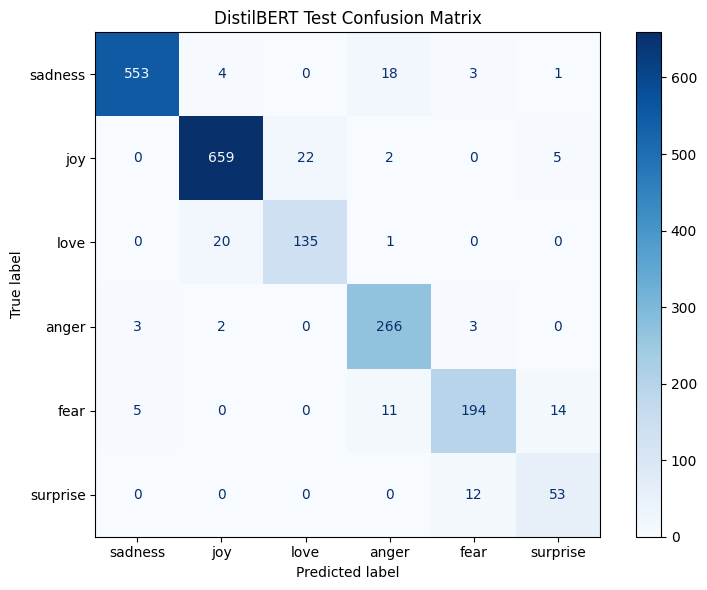

In [64]:
distilbert_test_cm = confusion_matrix(
    y_test,
    distilbert_test_predictions
)

display = ConfusionMatrixDisplay(
    confusion_matrix=distilbert_test_cm,
    display_labels=label_names
)

fig, ax = plt.subplots(figsize=(8, 6))

display.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

plt.title("DistilBERT Test Confusion Matrix")
plt.tight_layout()
plt.show()

The DistilBERT confusion matrix shows strong performance across all six emotion classes. The main remaining errors occur between semantically related emotions, particularly joy and love, fear and surprise, and sadness and anger. These confusions indicate that even a contextual transformer model can struggle when emotional categories overlap or when a sentence expresses mixed feelings.

In [65]:
from sklearn.metrics import classification_report

baseline_report_dict = classification_report(
    y_test,
    baseline_test_predictions,
    target_names=label_names,
    output_dict=True,
    zero_division=0
)

distilbert_report_dict = classification_report(
    y_test,
    distilbert_test_predictions,
    target_names=label_names,
    output_dict=True,
    zero_division=0
)

per_class_comparison = pd.DataFrame({
    "Emotion": label_names,
    "Baseline F1": [
        baseline_report_dict[label]["f1-score"]
        for label in label_names
    ],
    "DistilBERT F1": [
        distilbert_report_dict[label]["f1-score"]
        for label in label_names
    ]
})

per_class_comparison["Improvement"] = (
    per_class_comparison["DistilBERT F1"]
    - per_class_comparison["Baseline F1"]
)

per_class_comparison.round(4)

,Emotion,Baseline F1,DistilBERT F1,Improvement
0,sadness,0.9251,0.9702,0.0450
1,joy,0.9172,0.9599,0.0427
2,love,0.7877,0.8626,0.0749
3,anger,0.8913,0.9301,0.0388
4,fear,0.8650,0.8899,0.0249
5,surprise,0.7059,0.7681,0.0622


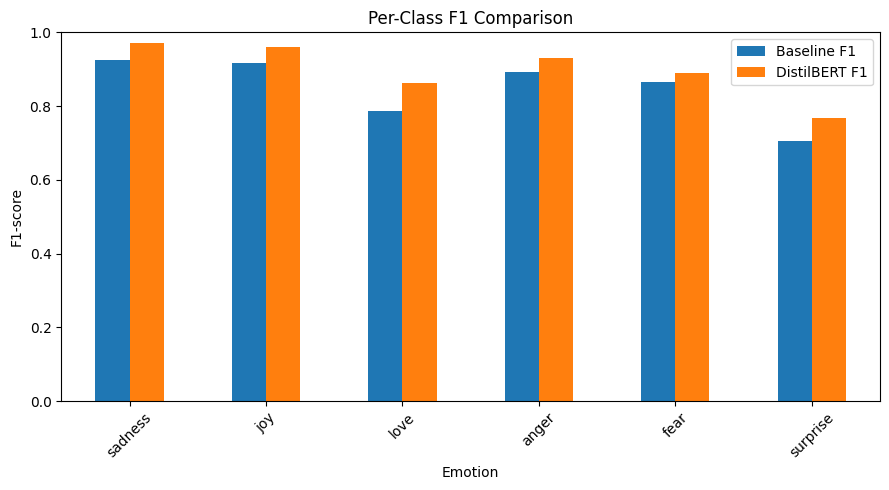

In [66]:
ax = per_class_comparison.plot(
    x="Emotion",
    y=["Baseline F1", "DistilBERT F1"],
    kind="bar",
    figsize=(9, 5)
)

ax.set_title("Per-Class F1 Comparison")
ax.set_xlabel("Emotion")
ax.set_ylabel("F1-score")
ax.set_ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()